# Noções de Lógica

**Módulo:** 01 – Conjuntos e Funções

**Pré-requisitos:** conteúdo de [00_fundamentos_e_python/](../00_fundamentos_e_python/) (Python básico: variáveis, `print`, booleanos, operadores `and`/`or`/`not`, listas simples)

**Objetivos de aprendizagem:**
- Reconhecer o que é uma proposição e distingui-la de sentenças que não têm valor lógico definido.
- Construir e ler tabelas-verdade para proposições compostas, condicionais e bicondicionais.
- Classificar uma proposição composta como tautologia, contradição ou contingência.
- Aplicar as relações de implicação e equivalência lógica, incluindo a negação correta de proposições (Leis de De Morgan).

**Tempo estimado:** 60 a 75 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/01_conjuntos_e_funcoes/01_nocoes_de_logica.ipynb)

## Um enigma para começar

Três suspeitos são interrogados sobre quem comeu o último pedaço do bolo:

- **Ana diz:** "Foi o Bruno."
- **Bruno diz:** "Não fui eu."
- **Caio diz:** "Ana está mentindo."

Sabe-se que **só uma dessas três frases é verdadeira**. Quem comeu o bolo?

Para resolver isso você precisa de uma coisa que parece óbvia, mas que a matemática trata com muito rigor: uma forma precisa de decidir quando uma frase é **verdadeira** ou **falsa**, e como isso se propaga quando combinamos várias frases numa só. É exatamente esse rigor — usado também pelos filtros de busca do Google ("gatos E cachorros NÃO cobras") e por toda condição `if` que você já escreveu em Python — que vamos construir neste notebook.

*Guarde o enigma do bolo: vamos resolvê-lo lá no fim, nos exercícios.*

## O que é uma proposição

- Uma **proposição** é uma sentença declarativa que tem um, e somente um, valor lógico: **verdadeiro (V)** ou **falso (F)** — nunca os dois, nunca nenhum.
- Perguntas, exclamações e ordens não são proposições, porque não fazem uma afirmação que possa ser julgada como verdadeira ou falsa.

📌 **Definição formal:**
- Wikipédia (PT): ["Proposição"](https://pt.wikipedia.org/wiki/Proposi%C3%A7%C3%A3o)

**Perguntas de checagem:**
1. "Silêncio, por favor" é proposição? Por quê?
2. E "o número 7 é primo"?

In [1]:
# Cada frase abaixo é classificada manualmente: True/False quando é uma
# proposição (com seu valor lógico), None quando a frase não é proposição.
frases: dict[str, bool | None] = {
    "O Brasil fica na América do Sul": True,
    "2 + 2 == 5": (2 + 2 == 5),
    "7 e um número primo": True,
    "Que dia lindo!": None,
    "Feche a porta.": None,
}

for frase, valor in frases.items():
    if valor is None:
        print(f"'{frase}' -> NÃO é proposição (sem valor lógico definido)")
    else:
        print(f"'{frase}' -> proposição, valor lógico: {valor}")

'O Brasil fica na América do Sul' -> proposição, valor lógico: True
'2 + 2 == 5' -> proposição, valor lógico: False
'7 e um número primo' -> proposição, valor lógico: True
'Que dia lindo!' -> NÃO é proposição (sem valor lógico definido)
'Feche a porta.' -> NÃO é proposição (sem valor lógico definido)


## Três formas de ver o mesmo valor lógico

- **Algébrica:** escrevemos V (verdadeiro) ou F (falso).
- **Numérica:** o Python guarda isso como `True`/`False`, que também se comportam como `1` e `0` (`True == 1`, `False == 0`).
- **Gráfica:** uma caixinha colorida para cada proposição, indicando seu valor.

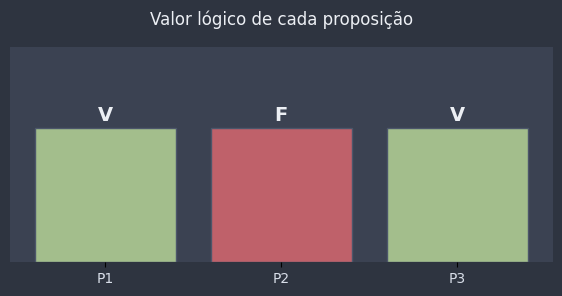

Numérico (int): {'P1': 1, 'P2': 0, 'P3': 1}


In [21]:
import matplotlib.pyplot as plt

proposicoes = {chave: valor for chave, valor in frases.items() if valor is not None}
cores = {True: "#A3BE8C", False: "#BF616A"}

fig, ax = plt.subplots(figsize=(7, 2.8))
fig.patch.set_facecolor("#2E3440")
ax.set_facecolor("#3B4252")

for i, valor in enumerate(proposicoes.values()):
    ax.bar(i, 1, color=cores[valor], edgecolor="#4C566A")
    ax.text(i, 1.05, "V" if valor else "F", ha="center", color="#ECEFF4",
             fontsize=14, fontweight="bold")

ax.set_xticks(range(len(proposicoes)))
ax.set_xticklabels([f"P{i + 1}" for i in range(len(proposicoes))], color="#D8DEE9")
ax.set_ylim(0, 1.6)
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title("Valor lógico de cada proposição", color="#ECEFF4", pad=16)
plt.show()

print("Numérico (int):", {f"P{i + 1}": int(v) for i, v in enumerate(proposicoes.values())})

## Sentenças abertas e quantificadores

- Uma **sentença aberta** é uma expressão com uma variável livre, como `x + 2 = 5`: ela não é verdadeira nem falsa até você fixar um valor para `x`.
- Para transformar uma sentença aberta numa proposição sem precisar fixar `x` à mão, usamos **quantificadores**:
    - **∀** (quantificador universal): "para todo x, ...".
    - **∃** (quantificador existencial): "existe x tal que ...".

📌 **Definição formal:**
- Wikipédia (PT): ["Quantificador"](https://pt.wikipedia.org/wiki/Quantificador)

**Pergunta de checagem:**
1. "x é primo" é proposição? E "∀x ∈ ℕ, x é primo"?

In [3]:
def sentenca_aberta(x: int) -> bool:
    '''x + 2 = 5 -> verdadeiro somente quando x = 3.'''
    return x + 2 == 5


# Testando a sentença aberta para vários valores de x
for x in range(0, 6):
    print(f"x = {x}: x + 2 = 5 é {sentenca_aberta(x)}")

x = 0: x + 2 = 5 é False
x = 1: x + 2 = 5 é False
x = 2: x + 2 = 5 é False
x = 3: x + 2 = 5 é True
x = 4: x + 2 = 5 é False
x = 5: x + 2 = 5 é False


💡 **Dica:** as funções `all()` e `any()` do Python são exatamente ∀ e ∃ em código — `all(...)` só é `True` quando **todos** os itens satisfazem a condição, e `any(...)` só é `True` quando **pelo menos um** satisfaz.

In [4]:
import ipywidgets as widgets

slider_inicio = widgets.IntSlider(value=-5, min=-20, max=0, description="inicio:")
slider_fim = widgets.IntSlider(value=5, min=0, max=20, description="fim:")


def testar_quantificadores(inicio: int, fim: int) -> None:
    '''Testa para-todo e existe sobre o intervalo [inicio, fim].'''
    valores = range(inicio, fim + 1)
    para_todo = all(x ** 2 >= 0 for x in valores)
    existe = any(x ** 2 == 4 for x in valores)
    print(f"Intervalo: [{inicio}, {fim}]")
    print(f"para-todo x, x^2 >= 0      ->  {para_todo}")
    print(f"existe x tal que x^2 = 4   ->  {existe}")


widgets.interact(testar_quantificadores, inicio=slider_inicio, fim=slider_fim)

interactive(children=(IntSlider(value=-5, description='inicio:', max=0, min=-20), IntSlider(value=5, descripti…

<function __main__.testar_quantificadores(inicio: int, fim: int) -> None>

## Negação de uma proposição

O operador de **negação** (¬, em Python `not`) inverte o valor lógico de uma proposição: se P é V, ¬P é F, e vice-versa.

| P | ¬P |
|---|---|
| V | F |
| F | V |

⚠️ **Erro comum:** negar "todo aluno gosta de matemática" como "nenhum aluno gosta de matemática" está errado — a negação correta é "existe pelo menos um aluno que não gosta de matemática". Vamos entender por que isso acontece mais à frente, na seção sobre as Leis de De Morgan.

**Pergunta de checagem:**
1. Qual o valor lógico de ¬(2 + 2 = 4)?

In [5]:
p = (2 + 2 == 4)
print(f"P: 2 + 2 == 4  ->  {p}")
print(f"not P          ->  {not p}")

P: 2 + 2 == 4  ->  True
not P          ->  False


## Proposições compostas e conectivos

- **Conjunção** (∧, em Python `and`): P ∧ Q é verdadeira somente quando P **e** Q são ambas verdadeiras.
- **Disjunção** (∨, em Python `or`): P ∨ Q é verdadeira quando **pelo menos uma** das duas é verdadeira.

| P | Q | P ∧ Q | P ∨ Q |
|---|---|---|---|
| V | V | V | V |
| V | F | F | V |
| F | V | F | V |
| F | F | F | F |

**Aplicação prática:** sistemas de acesso costumam usar exatamente essa lógica — por exemplo, "maior de idade E com cadastro ativo".

**Pergunta de checagem:**
1. Se P é V e Q é F, qual o valor de P ∨ Q? E de P ∧ Q?

In [6]:
import itertools

print("P      Q      P and Q    P or Q")
for p, q in itertools.product([True, False], repeat=2):
    print(f"{p!s:<6} {q!s:<6} {p and q!s:<10} {p or q!s}")

P      Q      P and Q    P or Q
True   True   True       True
True   False  False      True
False  True   False      True
False  False  False      False


In [7]:
maior_de_idade = True
cadastro_ativo = False

pode_acessar = maior_de_idade and cadastro_ativo
print(f"Maior de idade E cadastro ativo -> pode acessar: {pode_acessar}")

Maior de idade E cadastro ativo -> pode acessar: False


**Representação gráfica:** um diagrama simplificado, onde a região colorida mostra o que cada conectivo seleciona.

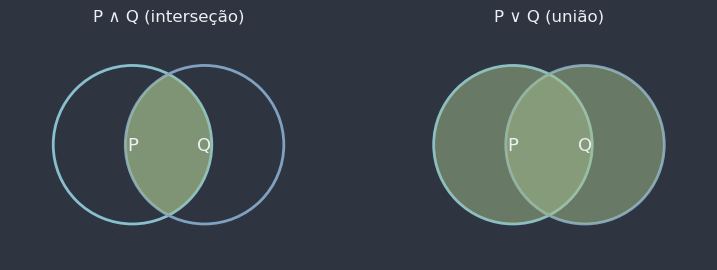

In [8]:
from matplotlib.patches import Circle

fig, axs = plt.subplots(1, 2, figsize=(9, 4.2))
fig.patch.set_facecolor("#2E3440")

centro_p, centro_q, raio = (-0.5, 0), (0.5, 0), 1.1

for ax, titulo, modo in zip(axs, ["P ∧ Q (interseção)", "P ∨ Q (união)"], ["and", "or"]):
    ax.set_facecolor("#2E3440")
    ax.add_patch(Circle(centro_p, raio, facecolor="none", edgecolor="#88C0D0", linewidth=2))
    ax.add_patch(Circle(centro_q, raio, facecolor="none", edgecolor="#81A1C1", linewidth=2))

    if modo == "and":
        destaque = Circle(centro_p, raio, facecolor="#A3BE8C", alpha=0.7, edgecolor="none")
        destaque.set_clip_path(Circle(centro_q, raio, transform=ax.transData))
        ax.add_patch(destaque)
    else:
        ax.add_patch(Circle(centro_p, raio, facecolor="#A3BE8C", alpha=0.5, edgecolor="none"))
        ax.add_patch(Circle(centro_q, raio, facecolor="#A3BE8C", alpha=0.5, edgecolor="none"))

    ax.set_xlim(-2.2, 2.2)
    ax.set_ylim(-1.6, 1.6)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(titulo, color="#ECEFF4")
    ax.text(*centro_p, "P", color="#ECEFF4", fontsize=13, ha="center", va="center")
    ax.text(*centro_q, "Q", color="#ECEFF4", fontsize=13, ha="center", va="center")

plt.show()

## Condicionais e bicondicionais

- **Condicional** (→): "se P, então Q". É **falsa somente** quando P é V e Q é F — em todos os outros casos, é verdadeira.
- **Bicondicional** (↔): "P se, e somente se, Q". É verdadeira quando P e Q têm o **mesmo** valor lógico.

| P | Q | P → Q | P ↔ Q |
|---|---|---|---|
| V | V | V | V |
| V | F | F | F |
| F | V | V | F |
| F | F | V | V |

⚠️ **Erro comum:** achar que P → Q é falso sempre que P é falso. Na verdade, quando o antecedente P é falso, o condicional inteiro é **automaticamente verdadeiro** — não importa o valor de Q.

**Aplicação prática:** "se chove, levo guarda-chuva". Os quatro casos da tabela correspondem a: choveu e levei (cumpri a promessa), choveu e não levei (quebrei a promessa), não choveu e levei (não fiz nada de errado), não choveu e não levei (também não fiz nada de errado).

**Pergunta de checagem:**
1. "Se 2 + 2 = 5, então a Terra é quadrada" — verdadeiro ou falso? Por quê?

In [9]:
def condicional(p: bool, q: bool) -> bool:
    '''P -> Q é falso somente quando p é verdadeiro e q é falso.'''
    return (not p) or q


def bicondicional(p: bool, q: bool) -> bool:
    '''P <-> Q é verdadeiro quando p e q tem o mesmo valor lógico.'''
    return p == q


print("P      Q      P -> Q    P <-> Q")
for p, q in itertools.product([True, False], repeat=2):
    print(f"{p!s:<6} {q!s:<6} {condicional(p, q)!s:<9} {bicondicional(p, q)!s}")

print()
print("2 + 2 = 5 -> Terra é quadrada:", condicional(2 + 2 == 5, False))

P      Q      P -> Q    P <-> Q
True   True   True      True
True   False  False     False
False  True   True      False
False  False  True      True

2 + 2 = 5 -> Terra é quadrada: True


## Tabela-verdade: construindo e verificando

O método sistemático para montar a tabela-verdade de uma proposição composta com **n** proposições simples é listar todas as **2ⁿ** combinações possíveis de V/F e calcular o valor da proposição composta em cada uma.

📌 **Definição formal:**
- Wikipédia (PT): ["Tabela verdade"](https://pt.wikipedia.org/wiki/Tabela-verdade)

**Pergunta de checagem:**
1. Quantas linhas tem a tabela-verdade de uma proposição com 3 variáveis?

In [10]:
import pandas as pd
from collections.abc import Callable


def tabela_verdade(
    proposicao: Callable[..., bool], nomes_variaveis: list[str]
) -> pd.DataFrame:
    '''Gera a tabela-verdade de uma proposição composta.

    Args:
        proposicao: função que recebe um bool por variável (na mesma ordem
            de `nomes_variaveis`) e devolve o valor lógico da composta.
        nomes_variaveis: nomes das variáveis, na ordem usada por `proposicao`.

    Returns:
        DataFrame com uma coluna por variável e uma coluna "resultado".
    '''
    linhas = []
    for valores in itertools.product([True, False], repeat=len(nomes_variaveis)):
        linha = dict(zip(nomes_variaveis, valores))
        linha["resultado"] = proposicao(*valores)
        linhas.append(linha)
    return pd.DataFrame(linhas)


# Exemplo: (P and Q) or (not P and Q)
tabela_verdade(lambda p, q: (p and q) or (not p and q), ["P", "Q"])

,P,Q,resultado
0,True,True,True
1,True,False,False
2,False,True,True
3,False,False,False


In [11]:
conectivos = {
    "P and Q": lambda p, q: p and q,
    "P or Q": lambda p, q: p or q,
    "P -> Q (condicional)": lambda p, q: condicional(p, q),
    "P <-> Q (bicondicional)": lambda p, q: bicondicional(p, q),
}

dropdown_conectivo = widgets.Dropdown(options=list(conectivos.keys()), description="Proposição:")


def montar_tabela(escolha: str) -> pd.DataFrame:
    return tabela_verdade(conectivos[escolha], ["P", "Q"])


widgets.interact(montar_tabela, escolha=dropdown_conectivo)

interactive(children=(Dropdown(description='Proposição:', options=('P and Q', 'P or Q', 'P -> Q (condicional)'…

<function __main__.montar_tabela(escolha: str) -> pandas.core.frame.DataFrame>

## Classificação: tautologia, contradição e contingência

- 📌 **Tautologia:** proposição composta que é **sempre verdadeira**, para qualquer combinação de valores das variáveis.
- 📌 **Contradição:** proposição composta que é **sempre falsa**.
- 📌 **Contingência:** proposição composta cujo valor lógico **depende** dos valores das variáveis.

**Curiosidade histórica:** a ideia de que toda proposição é V ou F, nunca as duas coisas, remonta a Aristóteles e é chamada de **princípio do terceiro excluído**.
- Wikipédia (PT): ["Princípio do terceiro excluído"](https://pt.wikipedia.org/wiki/Princ%C3%ADpio_do_terceiro_exclu%C3%ADdo)

**Pergunta de checagem:**
1. `(P → Q) ∨ (Q → P)` é tautologia, contradição ou contingência? Teste com a função abaixo antes de responder.

In [12]:
def classificar(proposicao: Callable[..., bool], n_variaveis: int) -> str:
    '''Classifica uma proposição composta em tautologia, contradição ou contingência.'''
    resultados = [
        proposicao(*valores)
        for valores in itertools.product([True, False], repeat=n_variaveis)
    ]
    if all(resultados):
        return "tautologia"
    if not any(resultados):
        return "contradição"
    return "contingência"


print("P or not P:", classificar(lambda p: p or not p, 1))
print("P and not P:", classificar(lambda p: p and not p, 1))
print(
    "(P -> Q) or (Q -> P):",
    classificar(lambda p, q: condicional(p, q) or condicional(q, p), 2),
)

P or not P: tautologia
P and not P: contradição
(P -> Q) or (Q -> P): tautologia


## Relação de implicação lógica e equivalência lógica

- **Implicação lógica** (P ⇒ Q): P implica logicamente Q quando P → Q é uma **tautologia**.
- **Equivalência lógica** (P ⇔ Q): P e Q são logicamente equivalentes quando P ↔ Q é uma **tautologia** — ou seja, as duas proposições têm exatamente a mesma tabela-verdade.

📌 **Definição formal:**
- Wikipédia (PT): ["Equivalência lógica"](https://pt.wikipedia.org/wiki/Equival%C3%AAncia_l%C3%B3gica)

**Aplicação prática:** é por isso que `not (not x)` é equivalente a `x` em qualquer programa — as duas expressões têm sempre o mesmo valor lógico.

**Pergunta de checagem:**
1. P ∧ Q é logicamente equivalente a Q ∧ P? Teste com a função abaixo.

In [13]:
def sao_equivalentes(
    prop_a: Callable[..., bool], prop_b: Callable[..., bool], n_variaveis: int
) -> bool:
    '''Verifica se duas proposições têm a mesma tabela-verdade.'''
    for valores in itertools.product([True, False], repeat=n_variaveis):
        if prop_a(*valores) != prop_b(*valores):
            return False
    return True


print("P and Q  ==  Q and P:", sao_equivalentes(lambda p, q: p and q, lambda p, q: q and p, 2))
print("not(not x) == x:     ", sao_equivalentes(lambda x: not (not x), lambda x: x, 1))

P and Q  ==  Q and P: True
not(not x) == x:      True


## Recíproca, contrária e contrapositiva

A partir de um condicional P → Q, definimos três variações:

| Nome | Forma |
|---|---|
| Original | P → Q |
| Recíproca | Q → P |
| Contrária | ¬P → ¬Q |
| Contrapositiva | ¬Q → ¬P |

⚠️ **Erro comum:** confundir contrapositiva com recíproca. A **contrapositiva é sempre equivalente ao original**; a recíproca, em geral, **não é**.

**Aplicação prática:** "se chove, a rua molha".
- Recíproca: "se a rua molha, então chove" (nem sempre é verdade — a rua pode ter molhado por outro motivo).
- Contrapositiva: "se a rua não molha, então não chove" (sempre equivalente à original).

**Pergunta de checagem:**
1. Dado "se chove, a rua molha", qual é a contrapositiva? Ela é logicamente equivalente à original?

In [14]:
original = lambda p, q: condicional(p, q)
reciproca = lambda p, q: condicional(q, p)
contraria = lambda p, q: condicional(not p, not q)
contrapositiva = lambda p, q: condicional(not q, not p)

print("Original == Recíproca:      ", sao_equivalentes(original, reciproca, 2))
print("Original == Contrária:      ", sao_equivalentes(original, contraria, 2))
print("Original == Contrapositiva: ", sao_equivalentes(original, contrapositiva, 2))
print("Contraria == Recíproca:     ", sao_equivalentes(contraria, reciproca, 2))

Original == Recíproca:       False
Original == Contrária:       False
Original == Contrapositiva:  True
Contraria == Recíproca:      True


## Como negar proposições (Leis de De Morgan)

📌 **Definição formal — Leis de De Morgan:**
- ¬(P ∧ Q) ⇔ ¬P ∨ ¬Q
- ¬(P ∨ Q) ⇔ ¬P ∧ ¬Q
- Negação do condicional: ¬(P → Q) ⇔ P ∧ ¬Q
- Negação dos quantificadores: ¬(∀x, P(x)) ⇔ ∃x, ¬P(x); e ¬(∃x, P(x)) ⇔ ∀x, ¬P(x)

**Conexão:** agora dá para resolver certinho o erro comum apontado lá na seção de Negação de uma proposição. Negar "todo aluno gosta de matemática" (∀x, gosta(x)) não é "nenhum aluno gosta" — é "existe pelo menos um aluno que não gosta" (∃x, ¬gosta(x)).

**Perguntas de checagem:**
1. Negue "estudo e passo".
2. Negue "todo aluno passou na prova".

In [15]:
print(
    "not(P and Q) == (not P) or (not Q):",
    sao_equivalentes(lambda p, q: not (p and q), lambda p, q: (not p) or (not q), 2),
)
print(
    "not(P or Q)  == (not P) and (not Q):",
    sao_equivalentes(lambda p, q: not (p or q), lambda p, q: (not p) and (not q), 2),
)
print(
    "not(P -> Q)  == P and (not Q):",
    sao_equivalentes(lambda p, q: not condicional(p, q), lambda p, q: p and (not q), 2),
)

not(P and Q) == (not P) or (not Q): True
not(P or Q)  == (not P) and (not Q): True
not(P -> Q)  == P and (not Q): True


In [16]:
# gosta[i] indica se o aluno i gosta de matematica
gosta_de_matematica = [True, True, False, True]

para_todo_gostam = all(gosta_de_matematica)
existe_que_nao_gosta = any(not gosta for gosta in gosta_de_matematica)

# De Morgan garante que estas duas linhas são sempre opostas uma da outra
print("para-todo aluno gosta de matemática:", para_todo_gostam)
print("not(para-todo) == existe que não gosta:", (not para_todo_gostam) == existe_que_nao_gosta)

para-todo aluno gosta de matemática: False
not(para-todo) == existe que não gosta: True


## Resumo

| Símbolo | Nome | Python |
|---|---|---|
| ¬P | negação | `not p` |
| P ∧ Q | conjunção | `p and q` |
| P ∨ Q | disjunção | `p or q` |
| P → Q | condicional | `(not p) or q` |
| P ↔ Q | bicondicional | `p == q` |
| ∀x | para todo x | `all(...)` |
| ∃x | existe x | `any(...)` |

| P | Q | ¬P | P∧Q | P∨Q | P→Q | P↔Q |
|---|---|---|---|---|---|---|
| V | V | F | V | V | V | V |
| V | F | F | F | V | F | F |
| F | V | V | F | V | V | F |
| F | F | V | F | F | V | V |

- **Tautologia:** sempre V. **Contradição:** sempre F. **Contingência:** depende dos valores.
- **Implicação lógica** (P ⇒ Q): P → Q é tautologia. **Equivalência lógica** (P ⇔ Q): P ↔ Q é tautologia (mesma tabela-verdade).

| A partir de P → Q | Forma | Equivalente ao original? |
|---|---|---|
| Recíproca | Q → P | não, em geral |
| Contrária | ¬P → ¬Q | não, em geral |
| Contrapositiva | ¬Q → ¬P | sim, sempre |

- **De Morgan:** ¬(P∧Q) ⇔ ¬P∨¬Q  |  ¬(P∨Q) ⇔ ¬P∧¬Q
- **Negação de quantificadores:** ¬(∀x, P(x)) ⇔ ∃x, ¬P(x)  |  ¬(∃x, P(x)) ⇔ ∀x, ¬P(x)

## Exercícios

**Básico**
1. Classifique frases soltas como proposição (com valor lógico) ou não-proposição.
2. Monte a tabela-verdade de "P ∨ ¬Q" usando a função `tabela_verdade`.
3. Negue proposições simples (sem quantificador).

**Intermediário**
1. Classifique proposições compostas como tautologia, contradição ou contingência.
2. Determine se dois pares de proposições são logicamente equivalentes.
3. Escreva a recíproca, a contrária e a contrapositiva de um condicional dado.

**Desafio**
1. Aplique De Morgan para negar uma proposição com quantificador e conectivo combinados.
2. Resolva o enigma do bolo (do início do notebook) usando busca por força bruta.

Resolva cada exercício substituindo as reticências `...` e rode a célula de verificação em seguida para conferir sua resposta.

O gabarito comentado de todos os exercícios está em [`01_nocoes_de_logica_gabarito.ipynb`](01_nocoes_de_logica_gabarito.ipynb) — só dê uma olhada depois de tentar por conta própria.

In [ ]:
# Exercício Básico 1: classifique cada frase.
# Para cada uma, atribua True (proposição verdadeira), False (proposição
# falsa) ou None (não é proposição)

valor_frase_1 = ...  # "O Sol é uma estrela"
valor_frase_2 = ...  # "3 * 3 == 8"
valor_frase_3 = ...  # "Que horas são?"

print(valor_frase_1, valor_frase_2, valor_frase_3)

In [ ]:
# Verificação
assert valor_frase_1 is True, (
    "Tente de novo, revise o passo 1: 'O Sol é uma estrela' é uma proposição verdadeira."
)
assert valor_frase_2 is False, (
    "Tente de novo, revise o passo 1: 3 * 3 = 9, então a frase é uma proposição falsa."
)
assert valor_frase_3 is None, (
    "Tente de novo, revise o passo 1: uma pergunta não tem valor lógico, nao é proposição."
)
print("Certo!")

In [ ]:
# Exercício Básico 2: monte a tabela-verdade de "P or (not Q)"
tabela = tabela_verdade(..., ["P", "Q"])
tabela

In [ ]:
# Verificação
assert list(tabela["resultado"]) == [True, True, False, True], (
    "Tente de novo, revise o passo 2: a proposição deveria ser 'P or (not Q)'."
)
print("Certo!")

In [ ]:
# Exercício Básico 3: negue as proposições abaixo
p1 = True  # "Estuda matemática"
negacao_p1 = ...  # negue p1

p2 = False  # "Choveu ontem"
negacao_p2 = ...  # negue p2

print(negacao_p1, negacao_p2)

In [ ]:
# Verificação
assert negacao_p1 == (not p1), "Tente de novo, revise o passo 3: negue p1 com 'not'."
assert negacao_p2 == (not p2), "Tente de novo, revise o passo 3: negue p2 com 'not'."
print("Certo!")

In [ ]:
# Exercício Intermediário 1: classifique cada proposição usando "classificar"
classe_1 = ...  # classifique "P or not P" (1 variável)
classe_2 = ...  # classifique "P and not P" (1 variável)
classe_3 = ...  # classifique "P and Q" (2 variáveis)

print(classe_1, classe_2, classe_3)

In [ ]:
# Verificação
assert classe_1 == "tautologia", "Tente de novo, revise o passo 1: 'P or not P' é sempre verdadeira."
assert classe_2 == "contradição", "Tente de novo, revise o passo 1: 'P and not P' é sempre falsa."
assert classe_3 == "contingência", "Tente de novo, revise o passo 1: 'P and Q' depende dos valores."
print("Certo!")

In [ ]:
# Exercício Intermediário 2: use "sao_equivalentes" para responder
equivalente_1 = ...  # (P -> Q) e (not P) or Q são equivalentes? (2 variáveis)
equivalente_2 = ...  # (P or Q) e (P and Q) são equivalentes? (2 variáveis)

print(equivalente_1, equivalente_2)

In [ ]:
# Verificação
assert equivalente_1 is True, (
    "Tente de novo, revise o passo 2: (P -> Q) e (not P) or Q têm a mesma tabela-verdade."
)
assert equivalente_2 is False, (
    "Tente de novo, revise o passo 2: (P or Q) e (P and Q) NÃO têm a mesma tabela-verdade."
)
print("Certo!")

In [ ]:
# Exercício Intermediário 3: dado "se estuda, então passa" (P: estuda, Q: passa),
# escreva a recíproca, a contrária e a contrapositiva como funções lambda
original_ex = lambda p, q: condicional(p, q)
reciproca_ex = ...       # Q -> P
contraria_ex = ...       # not P -> not Q
contrapositiva_ex = ...  # not Q -> not P

In [ ]:
# Verificação
assert sao_equivalentes(reciproca_ex, lambda p, q: condicional(q, p), 2), (
    "Tente de novo, revise o passo 3: a recíproca deveria ser Q -> P."
)
assert sao_equivalentes(contraria_ex, lambda p, q: condicional(not p, not q), 2), (
    "Tente de novo, revise o passo 3: a contrária deveria ser (not P) -> (not Q)."
)
assert sao_equivalentes(contrapositiva_ex, lambda p, q: condicional(not q, not p), 2), (
    "Tente de novo, revise o passo 3: a contrapositiva deveria ser (not Q) -> (not P)."
)
assert sao_equivalentes(original_ex, contrapositiva_ex, 2), (
    "Tente de novo: a contrapositiva deveria ser sempre equivalente a original."
)
print("Certo!")

In [ ]:
# Exercício Desafio 1: negando "para todo x, (P(x) -> Q(x))"
P = [True, True, False, True]
Q = [True, False, False, True]

proposicao_original = all(condicional(p, q) for p, q in zip(P, Q))

# Pela lei de De Morgan + negação de quantificador:
# not(para-todo x, P(x) -> Q(x))  ==  existe x, (P(x) and not Q(x))
negacao = ...  # escreva usando any(...)

print("Proposição original:", proposicao_original)
print("Negação:", negacao)

In [ ]:
# Verificação
assert negacao == (not proposicao_original), (
    "Tente de novo: pela lei de De Morgan, a negação deve ter sempre o valor "
    "oposto ao da proposição original."
)
print("Certo!")

In [ ]:
# Exercício Desafio 2: quem comeu o bolo?
# Ana diz: "Foi o Bruno"        -> ana_fala(quem)   == (quem == "Bruno")
# Bruno diz: "Não fui eu"       -> bruno_fala(quem) == (quem != "Bruno")
# Caio diz: "Ana está mentindo" -> caio_fala(quem)  == (not ana_fala(quem))
# Sabe-se que EXATAMENTE UMA das três falas é verdadeira.

suspeitos = ["Ana", "Bruno", "Caio"]


def ana_fala(quem: str) -> bool:
    return quem == "Bruno"


def bruno_fala(quem: str) -> bool:
    return quem != "Bruno"


def caio_fala(quem: str) -> bool:
    return not ana_fala(quem)


culpado = ...  # busque, entre os suspeitos, aquele para o qual exatamente 1 fala é verdadeira

print(f"O culpado é: {culpado}")

In [ ]:
# Verificação
def quantas_verdadeiras(quem: str) -> int:
    return sum([ana_fala(quem), bruno_fala(quem), caio_fala(quem)])


candidatos = [s for s in suspeitos if quantas_verdadeiras(s) == 1]
assert len(candidatos) == 1, "Revise as funções: deveria haver exatamente um suspeito consistente."
assert culpado == candidatos[0], (
    "Tente de novo, revise o passo: teste cada suspeito com 'quantas_verdadeiras'."
)
print("Certo!")

## Conexões

**Isso depende de:** [00_fundamentos_e_python/](../00_fundamentos_e_python/) (booleanos e operadores lógicos em Python)

**Isso será usado em:**
- `01_conjuntos_e_funcoes/02_...` (próximo notebook do módulo, sobre conjuntos, que usa diretamente pertencimento e quantificadores)
- Praticamente todo o resto do curso, como base de raciocínio (condições em geometria, prova de propriedades, etc.)